# 🇨🇳 China's Global Funding & Projects Analysis 📊

## 1️⃣ Required Libraries

In [1]:
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 

## 2️⃣ Read the Dataset

In [2]:
data_path = r'Dataset\ChineseFinancialPublicDiplomacyProjectDetails.xlsx'
df = pd.read_excel(data_path)

In [3]:
df.head()

,project_id,type,recommended_for_research,umbrella_project,donor,recipient,recipient_region,commitment_year,commitment_year_estimated,implementation_start_year,...,location_details,geojson_url_viz,geojson_url_dl,contact_name,contact_position,oda_eligible_recipient,source_quality_score,data_completeness_score,project_implementation_score,loan_detail_score
0,4,Financial,True,False,China,Angola,Africa,2001,False,2004.0,...,Luanda General Hospital (Hospital Geral de Lua...,https://github.com/aiddata/china-osm-geodata/b...,https://raw.githubusercontent.com/aiddata/chin...,Zhang Xiang; George Chicoty,;,True,5,5,5.0,5.0
1,6,Financial,True,False,China,Angola,Africa,2001,False,2001.0,...,"Bie Province, Angola",NaN,NaN,Albino Malungo,NaN,True,1,3,4.0,NaN
2,10,Financial,True,False,China,Angola,Africa,2000,False,NaN,...,NaN,NaN,NaN,Jiang Quyong; Domingos Culolo,;,True,1,2,NaN,NaN
3,13,Financial,True,False,China,Angola,Africa,2001,False,NaN,...,NaN,NaN,NaN,Jiang Yuande,NaN,True,1,2,1.0,NaN
4,14,Financial,True,False,China,Algeria,Africa,2003,False,2003.0,...,This project was designed to support earthquak...,NaN,NaN,Yue Mingsheng,NaN,True,5,4,5.0,NaN


## 3️⃣ Exploratory Data Analysis (EDA)

### Check Columns 

In [4]:
df.columns

Index(['project_id', 'type', 'recommended_for_research', 'umbrella_project',
       'donor', 'recipient', 'recipient_region', 'commitment_year',
       'commitment_year_estimated', 'implementation_start_year',
       'completion_year', 'title', 'description', 'staff_comments', 'status',
       'intent', 'flow_type', 'concessional', 'flow_class', 'sector_code',
       'sector_name', 'funding_agencies', 'funding_agencies_type',
       'cofinanced', 'cofinancing_agencies', 'cofinancing_agencies_type',
       'cofinancing_agencies_origin', 'receiving_agencies',
       'receiving_agencies_type', 'receiving_agencies_origin',
       'implementing_agencies', 'implementing_agencies_type',
       'implementing_agencies_origin', 'accountable_agencies',
       'accountable_agencies_type', 'accountable_agencies_origin',
       'amount_original_currency', 'original_currency',
       'amount_constant_usd2017', 'amount_nominal',
       'planned_implementation_start_date', 'planned_completion_date',
  

### Select Important Columns 

In [5]:
important_cols = [
    'project_id',
    'status',
    'type',
    'donor',
    'recipient',
    'recipient_region',
    'sector_name',
    'flow_type',
    'amount_nominal',
    'amount_constant_usd2017',
    'commitment_year',
    'implementation_start_year',
    'completion_year'
]
important_cols

['project_id',
 'status',
 'type',
 'donor',
 'recipient',
 'recipient_region',
 'sector_name',
 'flow_type',
 'amount_nominal',
 'amount_constant_usd2017',
 'commitment_year',
 'implementation_start_year',
 'completion_year']

### Select DataFrame Will Used 

In [6]:
df = df[important_cols]

In [7]:
df.head()

,project_id,status,type,donor,recipient,recipient_region,sector_name,flow_type,amount_nominal,amount_constant_usd2017,commitment_year,implementation_start_year,completion_year
0,4,Completion,Financial,China,Angola,Africa,Health,Loan,6.000000e+06,1.309537e+07,2001,2004.0,2006.0
1,6,Completion,Financial,China,Angola,Africa,Emergency Response,Grant,6.000000e+05,1.309537e+06,2001,2001.0,2001.0
2,10,Pipeline: Commitment,Financial,China,Angola,Africa,Government and Civil Society,Scholarships/training in the donor country,NaN,NaN,2000,NaN,NaN
3,13,Completion,Financial,China,Angola,Africa,Government and Civil Society,Grant,NaN,NaN,2001,NaN,NaN
4,14,Completion,Financial,China,Algeria,Africa,Emergency Response,Grant,6.040764e+05,1.277285e+06,2003,2003.0,2003.0


#### Shape

In [8]:
df.shape

(10741, 13)

#### Information

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10741 entries, 0 to 10740
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   project_id                 10741 non-null  int64  
 1   status                     10741 non-null  object 
 2   type                       10741 non-null  object 
 3   donor                      10741 non-null  object 
 4   recipient                  10741 non-null  object 
 5   recipient_region           10741 non-null  object 
 6   sector_name                10741 non-null  object 
 7   flow_type                  10741 non-null  object 
 8   amount_nominal             6473 non-null   float64
 9   amount_constant_usd2017    6473 non-null   float64
 10  commitment_year            10741 non-null  int64  
 11  implementation_start_year  5502 non-null   float64
 12  completion_year            6019 non-null   float64
dtypes: float64(4), int64(2), object(7)
memory usag

#### Description

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
project_id,10741.0,5.122425e+04,1.990435e+04,4.000000,38138.000000,5.637300e+04,6.501500e+04,8.829600e+04
amount_nominal,6473.0,1.152555e+08,6.495665e+08,140.049484,605000.000000,6.039747e+06,5.000000e+07,3.300000e+10
amount_constant_usd2017,6473.0,1.299707e+08,7.148323e+08,169.268450,896603.368192,8.199939e+06,6.049584e+07,3.206484e+10
commitment_year,10741.0,2.010799e+03,4.682159e+00,2000.000000,2007.000000,2.011000e+03,2.015000e+03,2.017000e+03
implementation_start_year,5502.0,2.011431e+03,4.627462e+00,1996.000000,2008.000000,2.012000e+03,2.015000e+03,2.021000e+03
completion_year,6019.0,2.012163e+03,4.683700e+00,2000.000000,2009.000000,2.013000e+03,2.016000e+03,2.021000e+03


### Check Missing Values 

In [11]:
df.isna().sum()

project_id                      0
status                          0
type                            0
donor                           0
recipient                       0
recipient_region                0
sector_name                     0
flow_type                       0
amount_nominal               4268
amount_constant_usd2017      4268
commitment_year                 0
implementation_start_year    5239
completion_year              4722
dtype: int64

In [12]:
missing_percent = (df[important_cols].isnull().sum() / len(df)) * 100
print(missing_percent.sort_values(ascending=False))

implementation_start_year    48.775719
completion_year              43.962387
amount_nominal               39.735593
amount_constant_usd2017      39.735593
project_id                    0.000000
status                        0.000000
type                          0.000000
donor                         0.000000
recipient                     0.000000
recipient_region              0.000000
sector_name                   0.000000
flow_type                     0.000000
commitment_year               0.000000
dtype: float64


In [13]:
df['implementation_start_year'] = df['implementation_start_year'].fillna('Unknown')
df['completion_year'] = df['completion_year'].fillna('Unknown')

#### Handling Missing Values

During the data preprocessing stage, missing values were identified in several variables, particularly `implementation_start_year` and `completion_year`. These missing values may indicate that a project had not yet started, had not yet been completed, or that the information was unavailable in the original data sources.

To preserve the maximum number of records and avoid losing potentially useful information, missing values in these two variables were replaced with the label **"Unknown"**. This approach allows missing information to be clearly distinguished from valid year values while maintaining dataset completeness for further analysis and visualization.

For financial variables such as `amount_nominal` and `amount_constant_usd2017`, missing values were retained as missing rather than being replaced with zero, since a missing funding value does not necessarily imply that the project received no funding. This helps prevent bias in financial analyses and ensures more accurate interpretations of funding patterns.


### Check Duplications

In [14]:
df.duplicated().sum()

0

### Fix Columns 

In [15]:
df['implementation_start_year'] = df['implementation_start_year'].fillna('Unknown')
df['completion_year'] = df['completion_year'].fillna('Unknown')

### **Analysis**

#### Number of Projects 

In [16]:
print('Number of Project :',df['project_id'].count())

Number of Project : 10741


#### Total Amount 

In [17]:
total_billion = df['amount_nominal'].sum() / 1e9
print(f'Total Amount on Projects: {total_billion:.2f} Billion')

Total Amount on Projects: 746.05 Billion


#### Status of Projects 

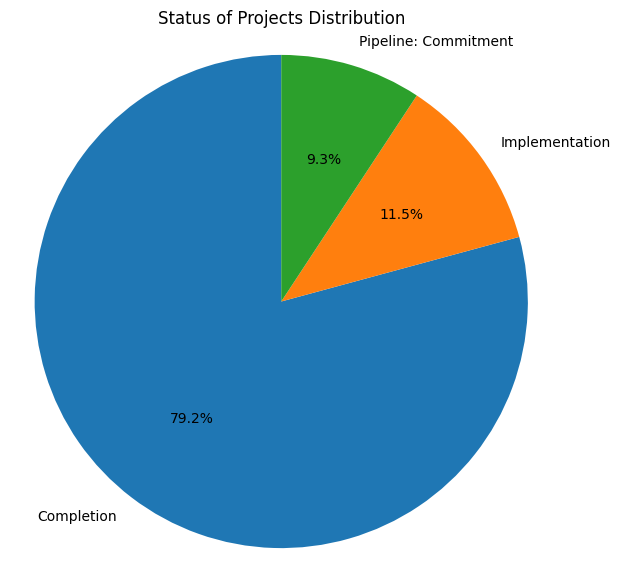

In [18]:
count = df['status'].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    count.values,
    labels=count.index,
    autopct='%1.1f%%', 
    startangle=90       
)

plt.title('Status of Projects Distribution')
plt.axis('equal') 
plt.show()

#### Regions include projects

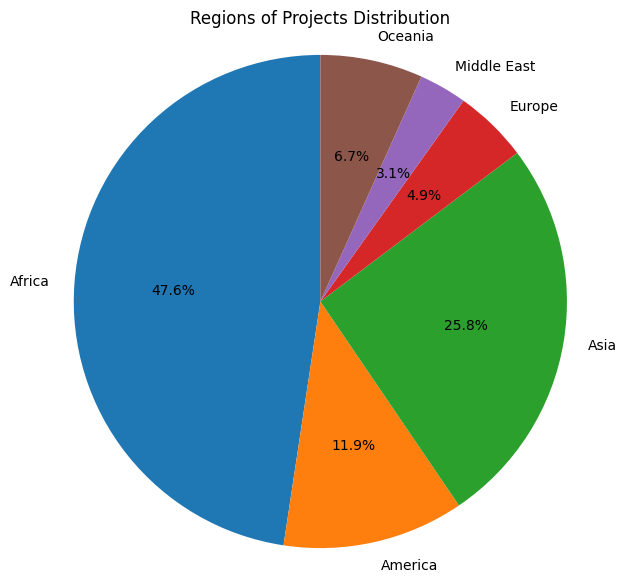

In [19]:
count = df['recipient_region'].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    count.values,
    labels=count.index,
    autopct='%1.1f%%', 
    startangle=90       
)

plt.title('Regions of Projects Distribution')
plt.axis('equal') 
plt.show()

#### Top Countries

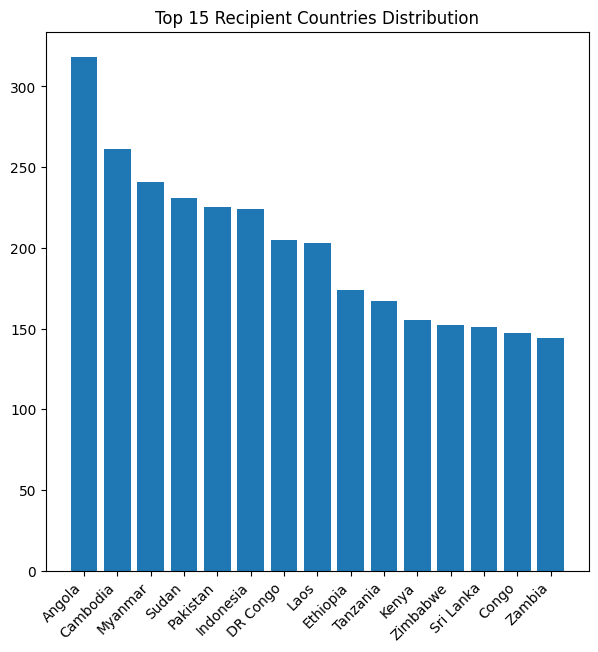

In [20]:
count = df['recipient'].value_counts().sort_values(ascending=False)[:15]

plt.figure(figsize=(7, 7))
plt.bar(
    x=count.index,
    height=count.values
)
plt.xticks(rotation=45, ha='right') 
plt.title('Top 15 Recipient Countries Distribution')
plt.show()

#### Top 3 Recipient Countries in Each Region by Number of Projects

In [21]:
top3 = (
    df.groupby(['recipient_region', 'recipient'])
      .size()
      .reset_index(name='project_count')
)

top3 = (
    top3.sort_values(
        ['recipient_region', 'project_count'],
        ascending=[True, False]
    )
    .groupby('recipient_region')
    .head(3)
)

top3 = top3.sort_values(
    ['recipient_region', 'project_count'],
    ascending=[True, False]
)

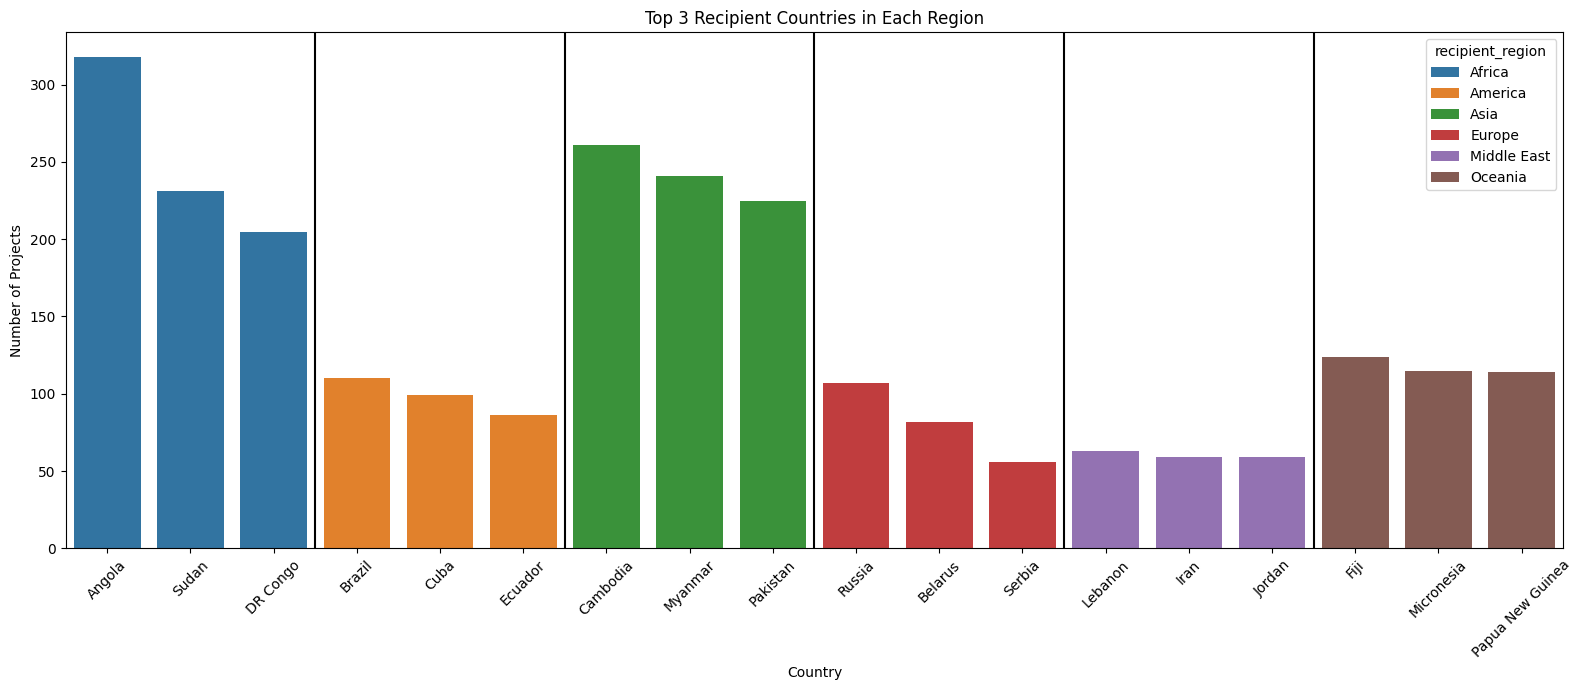

In [22]:
plt.figure(figsize=(16,7))

ax = sns.barplot(
    data=top3,
    x='recipient',
    y='project_count',
    hue='recipient_region',
    dodge=False
)

plt.title('Top 3 Recipient Countries in Each Region')
plt.xlabel('Country')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45)

regions = top3.groupby('recipient_region').size()

pos = 0
for region, size in regions.items():
    pos += size
    if pos < len(top3):
        plt.axvline(pos - 0.5, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

#### Top 10 Sectors 

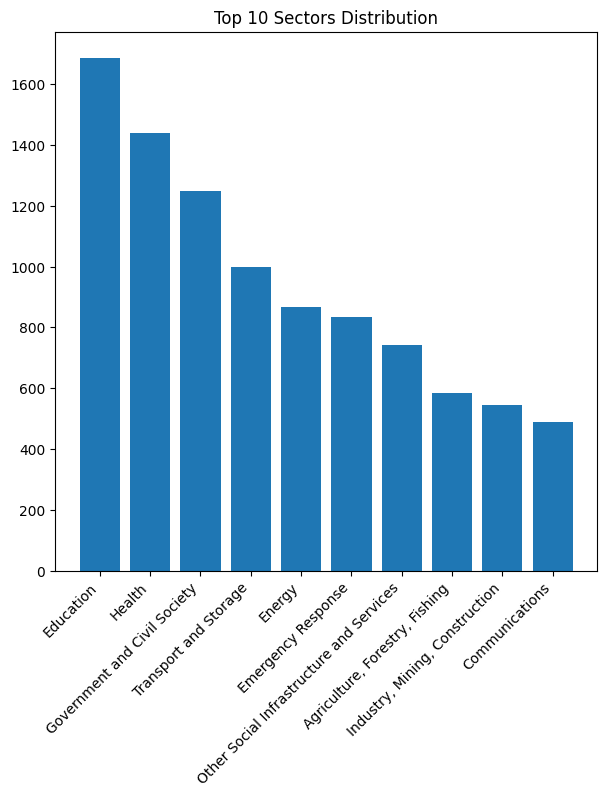

In [23]:
count = df['sector_name'].value_counts().sort_values(ascending=False)[:10]

plt.figure(figsize=(7, 7))
plt.bar(
    x=count.index,
    height=count.values
)
plt.xticks(rotation=45, ha='right') 
plt.title('Top 10 Sectors Distribution')
plt.show()

#### Top 3 Recipient Countries in Each Region by Total Funding 

In [24]:
top3 = (
    df.groupby(['recipient_region', 'recipient'])['amount_constant_usd2017']
      .sum()
      .reset_index(name='total_funding')
)

top3 = (
    top3.sort_values(
        ['recipient_region', 'total_funding'],
        ascending=[True, False]
    )
    .groupby('recipient_region')
    .head(3)
)

top3 = top3.sort_values(
    ['recipient_region', 'total_funding'],
    ascending=[True, False]
)

print(top3)

    recipient_region         recipient  total_funding
1             Africa            Angola   5.273234e+10
17            Africa          Ethiopia   1.595124e+10
45            Africa             Sudan   1.333078e+10
82           America         Venezuela   9.107860e+10
57           America            Brazil   4.145079e+10
65           America           Ecuador   1.694603e+10
92              Asia        Kazakhstan   4.232353e+10
91              Asia         Indonesia   3.490798e+10
101             Asia          Pakistan   3.464683e+10
118           Europe            Russia   1.253755e+11
111           Europe           Belarus   8.253168e+09
120           Europe            Turkey   6.814087e+09
122      Middle East              Iran   1.709280e+10
123      Middle East              Iraq   8.151810e+09
127      Middle East              Oman   5.408011e+09
139          Oceania  Papua New Guinea   6.097960e+09
135          Oceania  Marshall Islands   3.207946e+09
132          Oceania        

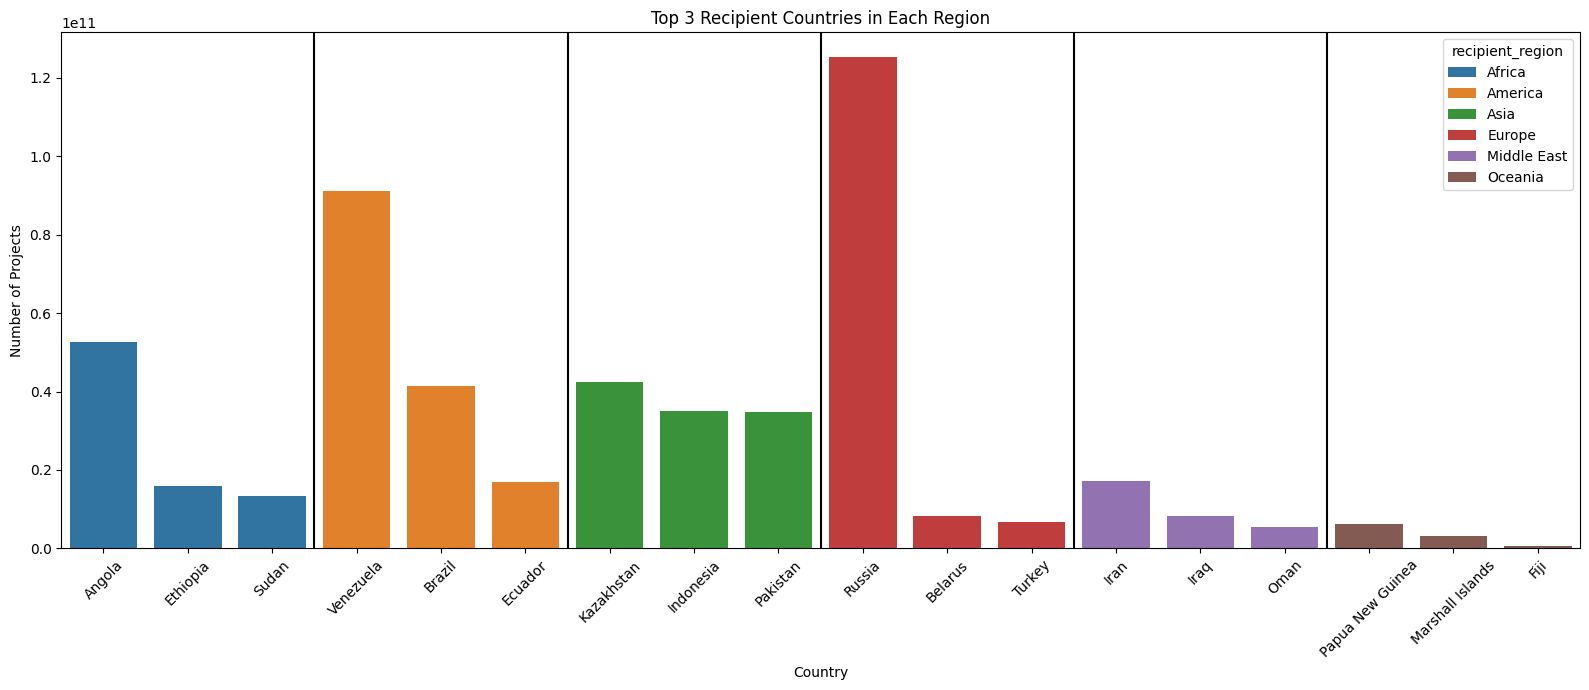

In [25]:
plt.figure(figsize=(16,7))

ax = sns.barplot(
    data=top3,
    x='recipient',
    y='total_funding',
    hue='recipient_region',
    dodge=False
)

plt.title('Top 3 Recipient Countries in Each Region')
plt.xlabel('Country')
plt.ylabel('Number of Projects')
plt.xticks(rotation=45)

regions = top3.groupby('recipient_region').size()

pos = 0
for region, size in regions.items():
    pos += size
    if pos < len(top3):
        plt.axvline(pos - 0.5, color='black', linewidth=1.5)

plt.tight_layout()
plt.show()

#### Top 10 Countries by Total Funding 

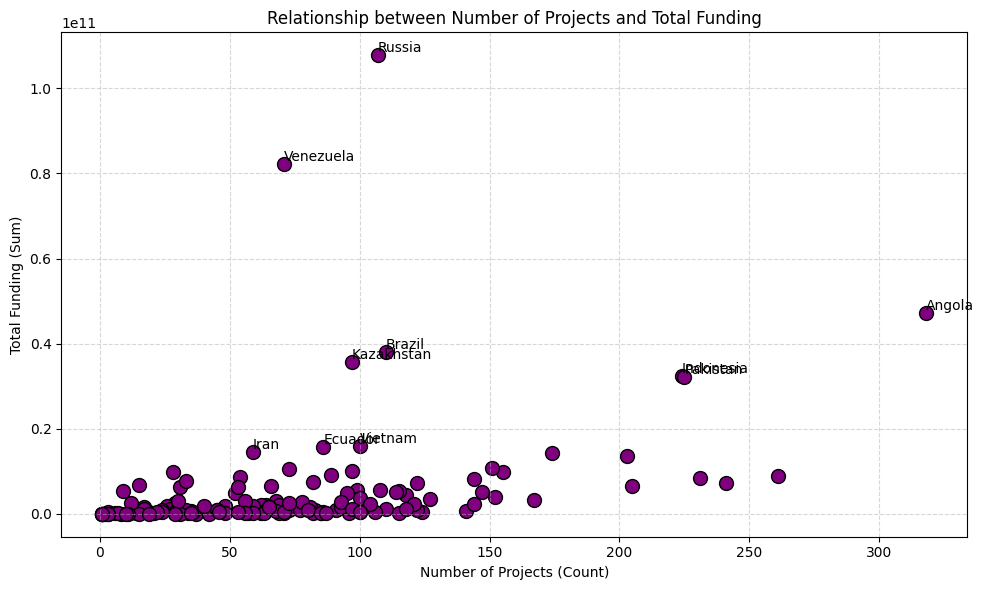

In [26]:
relation_data = df.groupby('recipient').agg(
    number_of_projects=('status', 'count'),      
    total_funding=('amount_nominal', 'sum')       
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    x=relation_data['number_of_projects'],
    y=relation_data['total_funding'],
    color='purple',       
    s=100,                
    edgecolors='black'   
)

top_countries = relation_data.sort_values(by='total_funding', ascending=False).head(10)
for country, row in top_countries.iterrows():
    ax.text(
        x=row['number_of_projects'],
        y=row['total_funding'],
        s=country,
        ha='left',         
        va='bottom',
    )

ax.set_title('Relationship between Number of Projects and Total Funding')
ax.set_xlabel('Number of Projects (Count)')
ax.set_ylabel('Total Funding (Sum)')
ax.grid(True, linestyle='--', alpha=0.5)  

plt.tight_layout()

#### Types of Funding 

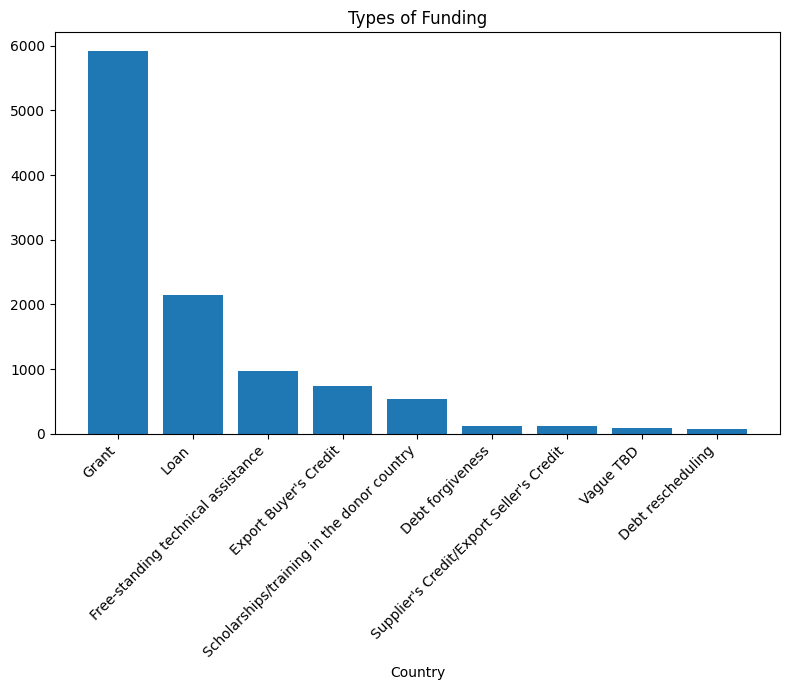

In [27]:
count = df['flow_type'].value_counts().sort_values(ascending=False)[:10]

plt.figure(figsize=(8, 7))
plt.bar(
    x=count.index,
    height=count.values,
)

plt.xticks(rotation=45, ha='right') 
plt.title('Types of Funding') 
plt.xlabel('Country')                         
plt.tight_layout()
plt.show()

#### Trend over time 

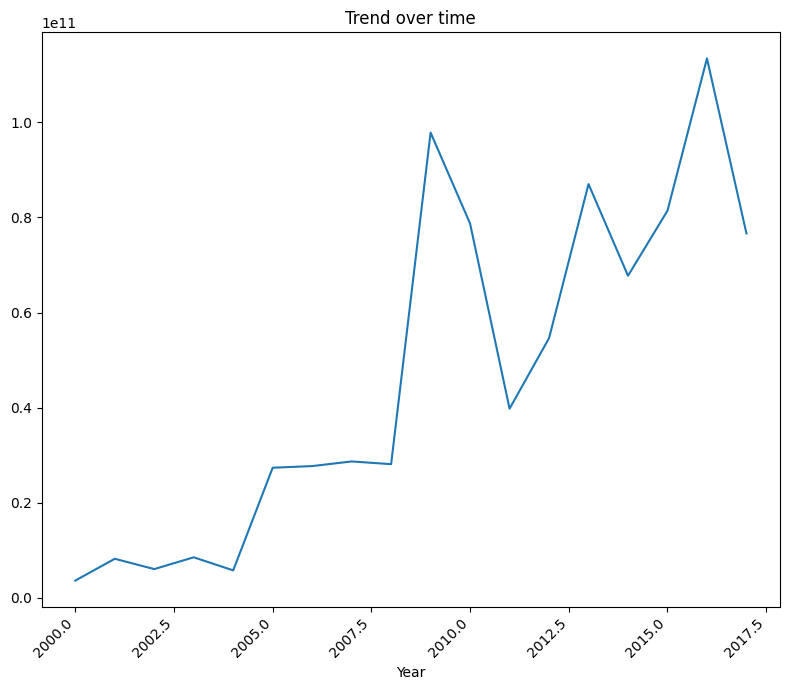

In [28]:
count = df.groupby('commitment_year')['amount_constant_usd2017'].sum()

plt.figure(figsize=(8, 7))
plt.plot(count.index, count.values)

plt.xticks(rotation=45, ha='right') 
plt.title('Trend over time') 
plt.xlabel('Year')                         
plt.tight_layout()
plt.show()

#### Distribution of Top 10 Sectors across Regions

In [29]:
top_10_sectors = df['sector_name'].value_counts().nlargest(10).index
filtered_df = df[df['sector_name'].isin(top_10_sectors)]
sector_region_matrix = pd.crosstab(filtered_df['recipient_region'], filtered_df['sector_name'])

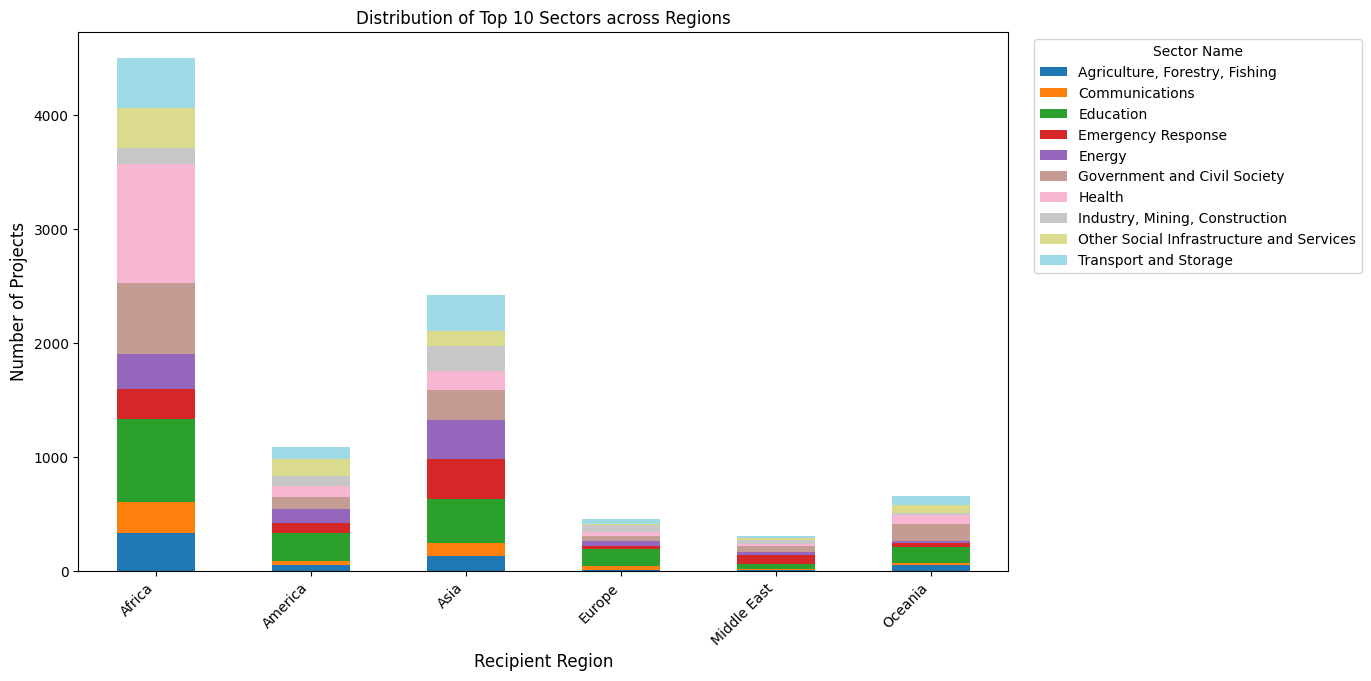

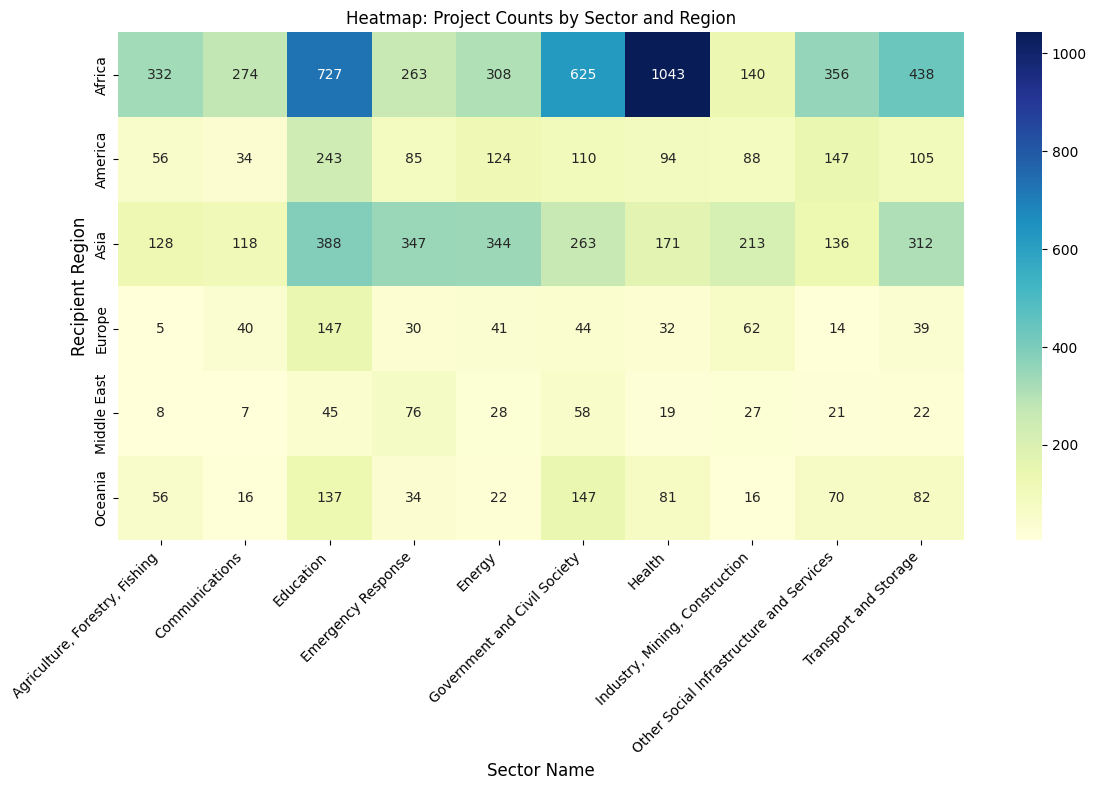

In [30]:
# 1
fig, ax = plt.subplots(figsize=(12, 7))
sector_region_matrix.plot(kind='bar', stacked=True, ax=ax, cmap='tab20')

ax.set_title('Distribution of Top 10 Sectors across Regions')
ax.set_xlabel('Recipient Region', fontsize=12)
ax.set_ylabel('Number of Projects', fontsize=12)
plt.xticks(rotation=45, ha='right')

ax.legend(title='Sector Name', bbox_to_anchor=(1.02, 1), loc='upper left')

# 2
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(sector_region_matrix, annot=True, fmt='d', cmap='YlGnBu', ax=ax, cbar=True)

ax.set_title('Heatmap: Project Counts by Sector and Region')
ax.set_xlabel('Sector Name', fontsize=12)
ax.set_ylabel('Recipient Region', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()

#### Duration Time of Projects 

In [31]:
df['implementation_start_year'] = pd.to_numeric(df['implementation_start_year'], errors='coerce')
df['completion_year'] = pd.to_numeric(df['completion_year'], errors='coerce')

df['years'] = df['completion_year'] - df['implementation_start_year']

In [32]:
avg_years = df['years'].mean()
print(f'Average Project Duration: {avg_years:.2f} years')

Average Project Duration: 1.27 years


## **Thank You** 🎀🫶🏻💌